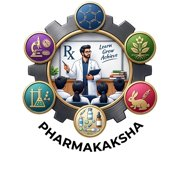

# BP801T · Unit V — Guided Project: Translational AI in Pharmacy
**Pharmakaksha · Learn · Grow · Achieve**
*Ethical Considerations and Translational Applications of AI in Pharmacy · B.Pharm Semester VIII · PCI NEP 2020*

This notebook contains every example and demo from the Unit V study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit5_Guided_Project_ADR_Prediction.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit5_Guided_Project_ADR_Prediction.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The models are for learning only. They are not clinical, regulatory or legal tools.

## 5.1 The project
**Translational AI** means taking a model from the notebook to the ward: build it, validate it, check it is legal, fair and safe, and plan how people will use it.

**Our worked project: an ADR risk tool for a hospital pharmacy.** Every new admission gets a risk score, and the clinical pharmacist reviews the highest-risk patients first.

| Step | What we do | Unit it builds on |
|---|---|---|
| 1 | Define the question and context of use | II |
| 2 | Protect privacy before analysis | III |
| 3 | Audit data quality | I |
| 4 | Build and cross-validate models | I |
| 5 | Test, choose a threshold, check calibration | I |
| 6 | Explain the model | II |
| 7 | Audit fairness | I |
| 8 | Regulatory and ethical analysis | II–IV |
| 9 | Model card and implementation plan | I–V |

### Step 1 — Question and context of use
- **Question of interest:** which newly admitted adults are at high risk of an ADR during this stay?
- **Context of use:** the score ranks patients for **pharmacist review within 24 hours**. The pharmacist decides; the model never changes a prescription.
- **Success criteria (set before modelling):** AUC ≥ 0.75 on held-out data; sensitivity ≥ 0.70 at the chosen threshold; no patient group with sensitivity more than 0.15 below the overall value.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

TEAL, GREEN, ORANGE, GREY = "#12303A", "#1F8A70", "#E07A2E", "#8A9BA3"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

raw = load("adr_project.csv")
print(raw.shape)
raw.head(3)

## Step 2 — Privacy first
The extract contains **direct identifiers** (name, mobile) and **quasi-identifiers** (date of birth, PIN code). Under India's DPDP Act we collect and keep only what the purpose needs (**data minimisation**). We:
1. replace the name with a pseudonymous ID (the key stays with the hospital),
2. drop the mobile number,
3. keep age in years instead of date of birth,
4. keep only the first three PIN digits.

In [ ]:
import hashlib

SALT = "hospital-secret-key"                 # stored separately, never shared with the analysts
data = raw.copy()
data.insert(0, "pid", [hashlib.sha256((SALT + n + d).encode()).hexdigest()[:10]
                       for n, d in zip(raw["patient_name"], raw["date_of_birth"])])
data["pin3"] = data["pin_code"].astype(str).str[:3]
data = data.drop(columns=["patient_name", "mobile", "date_of_birth", "pin_code"])
print("Columns kept:", list(data.columns))
band = np.clip(raw["age"] // 10 * 10, 20, 80)          # 10-year bands; under-30s and 80+ grouped
print("Smallest group sharing exact age + sex + full PIN:", raw.groupby(["age", "sex", "pin_code"]).size().min())
print("Smallest group sharing age band + sex + 3-digit PIN:", raw.assign(band=band, pin3=raw["pin_code"].astype(str).str[:3])
      .groupby(["band", "sex", "pin3"]).size().min())

Exact age + sex + PIN singles out some people (a "group" of one person). Age bands and a 3-digit PIN make every group large. We keep exact age for the **analysis**, which stays inside the hospital's secure environment; if the dataset is ever **shared**, it must use the banded version.

## Step 3 — Data quality audit

In [ ]:
print(f"ADR rate: {data['adr'].mean():.1%}   (n = {len(data)})")
print("\nMissing eGFR by area:")
print(data.groupby("rural")["egfr"].apply(lambda s: f"{s.isna().mean():.0%} missing").rename({0: "Urban", 1: "Rural"}))

**Red flag:** eGFR is missing for about a third of **rural** patients but few urban ones, because rural clinics often lack lab tests. Kidney function is a key ADR risk factor, so the model may work less well for rural patients. We will check this in Step 7. We add a **missing-value indicator**, so the model knows when eGFR was not measured.

## Step 4 — Build and cross-validate
We hold back 25% of patients as a final test set, and compare two models on the rest with 5-fold cross-validation. Pharmacology tells us that **anticoagulant + NSAID** together raise bleeding risk more than either alone, so we also try adding that **interaction** feature.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

data["female"] = (data["sex"] == "F").astype(int)
data["anticoag_x_nsaid"] = data["on_anticoagulant"] * data["on_nsaid"]
BASE = ["age", "female", "weight_kg", "egfr", "num_drugs", "on_anticoagulant", "on_nsaid", "prior_adr", "liver_disease"]
FULL = BASE + ["anticoag_x_nsaid"]

train, test = train_test_split(data, test_size=0.25, random_state=42, stratify=data["adr"])
cv = StratifiedKFold(5, shuffle=True, random_state=42)

def logistic():
    return make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(),
                         LogisticRegression(max_iter=1000))
def forest():
    return make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                         RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=42))

for name, make, feats in [("Logistic, base features", logistic, BASE),
                          ("Logistic + anticoagulant×NSAID", logistic, FULL),
                          ("Random forest + interaction", forest, FULL)]:
    s = cross_val_score(make(), train[feats], train["adr"], cv=cv, scoring="roc_auc")
    print(f"{name:<32} CV AUC = {s.mean():.3f} ± {s.std():.3f}")

Adding the pharmacology-based interaction lifts the cross-validated AUC from about 0.81 to 0.82, and this logistic model beats the random forest while staying easy to explain. We choose it.

## Step 5 — Threshold, test results and calibration
We choose the risk threshold on the **training** data (cross-validated predictions) so that sensitivity is at least 0.70. Then we score the test set **once**.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix, brier_score_loss

cv_risk = cross_val_predict(logistic(), train[FULL], train["adr"], cv=cv, method="predict_proba")[:, 1]
for thr in np.arange(0.30, 0.04, -0.01):
    if recall_score(train["adr"], cv_risk >= thr) >= 0.70:
        break
THRESHOLD = round(float(thr), 2)
print("Chosen threshold:", THRESHOLD)

model = logistic().fit(train[FULL], train["adr"])
test = test.copy()
test["risk"] = model.predict_proba(test[FULL])[:, 1]
test["flag"] = (test["risk"] >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(test["adr"], test["flag"]).ravel()
print(f"Test AUC = {roc_auc_score(test['adr'], test['risk']):.3f}")
print(f"Sensitivity = {tp / (tp + fn):.2f}   Specificity = {tn / (tn + fp):.2f}   PPV = {tp / (tp + fp):.2f}")
print(f"Flagged for review: {test['flag'].mean():.0%} of patients  (TP {tp}, FP {fp}, FN {fn}, TN {tn})")
print(f"Brier = {brier_score_loss(test['adr'], test['risk']):.3f}   mean predicted {test['risk'].mean():.1%} vs observed {test['adr'].mean():.1%}")

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
fpr, tpr, _ = roc_curve(test["adr"], test["risk"])
ax[0].plot(fpr, tpr, color=GREEN, linewidth=2, label=f"AUC = {roc_auc_score(test['adr'], test['risk']):.2f}")
ax[0].plot([0, 1], [0, 1], color=GREY, linestyle="--")
ax[0].set_xlabel("1 − specificity"); ax[0].set_ylabel("Sensitivity"); ax[0].legend(); ax[0].set_title("ROC curve (test set)")
obs, pred = calibration_curve(test["adr"], test["risk"], n_bins=5, strategy="quantile")
ax[1].plot(pred, obs, "o-", color=ORANGE, label="Model")
ax[1].plot([0, 0.5], [0, 0.5], color=GREY, linestyle="--", label="Perfect calibration")
ax[1].set_xlabel("Predicted ADR risk"); ax[1].set_ylabel("Observed ADR rate"); ax[1].legend()
ax[1].set_title("Calibration (test set, 5 groups)")
plt.tight_layout(); plt.show()

## Step 6 — Explain the model
Odds ratios from the final model (refitted with statsmodels so we get confidence intervals). Missing eGFR is filled with the median here, as in the pipeline.

In [ ]:
import statsmodels.api as sm

Xs = train[FULL].copy()
Xs["egfr_missing"] = Xs["egfr"].isna().astype(int)
Xs["egfr"] = Xs["egfr"].fillna(train["egfr"].median())
fit = sm.Logit(train["adr"], sm.add_constant(Xs)).fit(disp=0)
OR = pd.DataFrame({"odds_ratio": np.exp(fit.params), "CI_low": np.exp(fit.conf_int()[0]),
                   "CI_high": np.exp(fit.conf_int()[1])}).drop("const").round(2)
print(OR.sort_values("odds_ratio", ascending=False))

Every direction makes pharmacological sense. The **anticoagulant + NSAID** combination is the strongest factor (OR about 6), while either drug alone adds little: exactly the interaction pharmacology predicts. Prior ADR and liver disease each roughly triple the odds, each extra drug adds about 27%, and each extra mL/min of eGFR lowers the odds (OR 0.96). A **missing** eGFR itself raises risk (OR 2.3): the missingness carries information. A pharmacist can **trust and challenge** a model they can read.

## Step 7 — Fairness audit
Does the tool work equally well for every group? We use the test set and the chosen threshold.

In [ ]:
test["age_group"] = pd.cut(test["age"], [0, 65, 200], labels=["< 65", "65+"], right=False)
test["area"] = test["rural"].map({0: "Urban", 1: "Rural"})
rows = []
for col in ["sex", "age_group", "area"]:
    for g, s in test.groupby(col, observed=True):
        rows.append({"group": f"{col}: {g}", "n": len(s), "ADRs": int(s["adr"].sum()),
                     "sensitivity": round(recall_score(s["adr"], s["flag"]), 2),
                     "AUC": round(roc_auc_score(s["adr"], s["risk"]), 2),
                     "flagged %": round(100 * s["flag"].mean())})
fair = pd.DataFrame(rows)
overall = recall_score(test["adr"], test["flag"])
fair["gap vs overall"] = (fair["sensitivity"] - overall).round(2)
print(f"Overall sensitivity = {overall:.2f}")
print(fair.to_string(index=False))

In [ ]:
plt.figure(figsize=(8, 4))
colours = [ORANGE if g < -0.15 else GREEN for g in fair["gap vs overall"]]
plt.barh(fair["group"], fair["sensitivity"], color=colours)
plt.axvline(overall, color=TEAL, linestyle="--", label=f"Overall {overall:.2f}")
plt.axvline(overall - 0.15, color=GREY, linestyle=":", label="Success limit (overall − 0.15)")
plt.xlabel("Sensitivity at the chosen threshold"); plt.xlim(0, 1); plt.legend(fontsize=8)
plt.title("Fairness audit: does every group get the same protection?")
plt.tight_layout(); plt.show()

Every group is within 0.15 of the overall sensitivity, so the **success criterion is met**. But each group has only about 20 test ADRs, so these numbers are noisy. We repeat the rural/urban check with cross-validated predictions on the larger training set.

In [ ]:
tr = train.copy()
tr["risk"] = cv_risk
tr["flag"] = (tr["risk"] >= THRESHOLD).astype(int)
for area, s in tr.groupby("rural"):
    print(f"{'Rural' if area else 'Urban':<6} n = {len(s):>3}  ADRs = {int(s['adr'].sum()):>3}  "
          f"sensitivity = {recall_score(s['adr'], s['flag']):.2f}  AUC = {roc_auc_score(s['adr'], s['risk']):.2f}  "
          f"eGFR missing = {s['egfr'].isna().mean():.0%}")

**Finding:** sensitivity is similar, but the model **ranks rural patients less well** (AUC 0.78 vs 0.83). Their eGFR is missing four times out of ten, so the model is partly "flying blind" on kidney function for them. Passing a numeric criterion is not the end of an audit. Mitigations, in order of preference:
1. **Fix the data:** point-of-care creatinine testing in rural clinics.
2. **Workflow safeguard:** any patient with missing eGFR **and** age ≥ 65 or ≥ 5 drugs goes to pharmacist review regardless of score.
3. **Report it** in the model card and re-audit after deployment.

## Step 8 — Regulatory and ethical analysis

In [ ]:
def model_risk(influence, consequence):
    score = {"low": 1, "medium": 2, "high": 3}
    s = score[influence] + score[consequence]
    return "High" if s >= 5 else "Medium" if s >= 4 else "Low"

assessment = {
    "FDA-style model risk": model_risk("medium", "high") + " (pharmacist decides = medium influence; missed ADR can harm = high consequence)",
    "CDSCO MDSW class": "Likely Class B if regulated as SaMD (serious situation, drives clinical management); confirm with CDSCO",
    "EU AI Act (if sold in EU)": "High risk if it is a medical device needing notified-body review; duties apply from 2 Aug 2028",
    "India DPDP Act 2023": "Health data of patients: lawful purpose, notice, security, breach reporting, deletion",
    "ICMR AI ethics (2023)": "Autonomy, safety, data privacy, accountability, fairness, validity — all addressed below",
}
for k, v in assessment.items():
    print(f"{k:<26}: {v}")

In [ ]:
risk_register = pd.DataFrame([
    ["Bias", "Lower accuracy for rural patients (missing eGFR)", "High", "Review rule for missing eGFR; rural point-of-care tests; re-audit quarterly"],
    ["Privacy", "Re-identification from age + sex + PIN", "Medium", "Pseudonymise; age bands if shared; access control; DPDP-compliant notice"],
    ["Automation bias", "Pharmacists stop checking low-score patients", "Medium", "Training; score shown as 'priority', not 'safe'; audit overrides"],
    ["Drift", "New drugs or patient mix change risk", "Medium", "Monthly PSI and calibration checks; retrain under change control"],
    ["Accountability", "Unclear who answers for a missed ADR", "High", "Named clinical owner; pharmacist remains decision-maker; audit trail"],
    ["Transparency", "Patients unaware AI is used", "Low", "Notice in admission leaflet; explanation on request"],
], columns=["Risk", "Description", "Severity", "Mitigation"])
print(risk_register.to_string(index=False))

## Step 9 — Model card and implementation plan

In [ ]:
card = {
    "Name / version": "ADR priority score v1.0 (logistic regression with anticoagulant×NSAID term)",
    "Intended use": "Rank adult inpatients for clinical-pharmacist review within 24 h. Decision support only.",
    "Not for": "Children; outpatients; stopping or changing drugs without pharmacist review",
    "Data": f"{len(data)} admissions (fictional teaching data); identifiers removed; {data['adr'].mean():.0%} ADR rate",
    "Performance (test)": f"AUC {roc_auc_score(test['adr'], test['risk']):.2f}; sensitivity {overall:.2f} at threshold {THRESHOLD}",
    "Known limits": "Weaker for rural patients with missing eGFR; not validated outside this hospital",
    "Monitoring": "Monthly calibration and PSI; quarterly fairness audit; retrain if gaps exceed limits",
    "Owner": "Drug & Therapeutics Committee; clinical pharmacy lead",
}
for k, v in card.items():
    print(f"{k:<20}: {v}")

**Implementation plan (phased roll-out)**

| Phase | Duration | What happens | Go / no-go check |
|---|---|---|---|
| 1. Silent mode | 3 months | Score runs in the background; pharmacists work as usual | Real-world AUC and calibration match the test set |
| 2. Pilot | 3 months | Scores shown on one ward; pharmacists record agreement | Review time, ADRs caught, override rate, user feedback |
| 3. Go-live | Ongoing | All wards; missing-eGFR safety rule active | Monthly monitoring dashboard; quarterly audit |
| 4. Review | Every 6–12 months | Re-validate; retrain if drift; update model card | Ethics/AI committee sign-off |

## Present your project
Your final presentation (8–10 slides) should cover: the problem and context of use → data and privacy steps → model and validation results → explanation → fairness audit → regulatory class and ethical risks → implementation plan → limitations.

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Change the target sensitivity to **0.80**. What threshold do you get, and what share of test patients is flagged? What is the cost of catching more ADRs?

**2.** Remove `female` from the features and refit. Does the test AUC change? Discuss: should sex be used in a clinical model?

**3.** Among **rural** patients in the training set (use `tr`, which has cross-validated risks), compare the AUC for patients **with** and **without** a measured eGFR. What does this tell you about the cause of the rural gap?

**4. Your own project.** Pick one topic and repeat Steps 1–9:
- **Stability forecasting** — `stability.csv` (BP201T Unit V)
- **QC failure model** — `dissolution_batches.csv` (BP301T)
- **Demand prediction** — `pharmacy_demand.csv` (Unit III)
- **Medication adherence** — `adherence_patients.csv` + `refill_records.csv` (Unit III)
- **Disease risk prediction** — `diabetes_survey.csv` (Unit IV)

---
## Solutions

In [ ]:
# 1
for thr80 in np.arange(0.30, 0.02, -0.01):
    if recall_score(train["adr"], cv_risk >= thr80) >= 0.80:
        break
flag80 = test["risk"] >= thr80
print(f"Threshold {thr80:.2f}: test sensitivity {recall_score(test['adr'], flag80):.2f}, flagged {flag80.mean():.0%} of patients")
# More ADRs caught, but more patients to review (more false alarms, more pharmacist time).

In [ ]:
# 2
no_sex = [f for f in FULL if f != "female"]
m2 = logistic().fit(train[no_sex], train["adr"])
print(f"AUC without sex = {roc_auc_score(test['adr'], m2.predict_proba(test[no_sex])[:, 1]):.3f}")
# Sex adds little once weight and eGFR are in. Keep a protected attribute only if it improves care
# for that group, and always audit by it.

In [ ]:
# 3
rural = tr[tr["rural"] == 1]
for measured, s in rural.groupby(rural["egfr"].notna()):
    print(f"eGFR {'measured' if measured else 'missing '}: n = {len(s)}, ADRs = {int(s['adr'].sum())}, AUC = {roc_auc_score(s['adr'], s['risk']):.2f}")
# The model ranks patients less well when eGFR is missing: the gap comes from missing data, not from being rural.

---
**Course complete.** You have followed an AI model from raw data to a deployment plan, with validation, explanation, fairness, privacy and regulation at every step. Pharmakaksha · Learn · Grow · Achieve